<a href="https://colab.research.google.com/github/ghanshyamverma4654/Mission-Data-Science/blob/master-branch/E_commerce_DB_Anaslysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#To ignore unwanted warnings
#import warnings
#warnings.filterwarnings('ignore')

In [5]:
data = pd.read_csv('data_export.csv')

In [6]:
data.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [7]:
#Allocating 0th row as columns name
data.columns = data.iloc[0]

In [8]:
#Removing Duplicate of 0th row
data = data[1:].reset_index(drop = True)
data.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [9]:
#Removing unwanted 1st column
#data = data.iloc[:, 1:]

In [10]:
#Renaming a few columns
data.rename(columns = {
    'Session primary channel group (Default channel group)':'Channel group',
    'Date + hour (YYYYMMDDHH)':'DateHour'
}, inplace = True)

In [11]:
data.head(3)

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069


In [12]:
#Checking for datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [13]:
#Changing datatype of column DataHour
data['DateHour'] = pd.to_datetime(data['DateHour'],format = '%Y%m%d%H')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   object        
 3   Sessions                             3182 non-null   object        
 4   Engaged sessions                     3182 non-null   object        
 5   Average engagement time per session  3182 non-null   object        
 6   Engaged sessions per user            3182 non-null   object        
 7   Events per session                   3182 non-null   object        
 8   Engagement rate                      3182 non-null   object        
 9   Event count                          3182 non-null   object        
dtypes: datetime6

In [15]:
#Creating a new column for Hours
data['Hours'] = data['DateHour'].dt.hour
data.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hours
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001,20


In [16]:
#Changing the datatype of all the columns excluding 'Channel group' and 'DateHour'
exclude_columns = data.columns.difference(['Channel group','DateHour'])

#Converting all remaining columns to numeric
data[exclude_columns] = data[exclude_columns].apply(pd.to_numeric)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hours       

In [17]:
#Cheacking if there is any null values
data.isna().sum()

,0
0,
Channel group,0
DateHour,0
Users,0
Sessions,0
Engaged sessions,0
Average engagement time per session,0
Engaged sessions per user,0
Events per session,0
Engagement rate,0


**Data is cleaned properly, And now we heads to data visualization...**

Q1: What pattern or trends can you observe in wesite sessions and users over time?

In [18]:
#setting style of plots
sns.set_style('darkgrid')

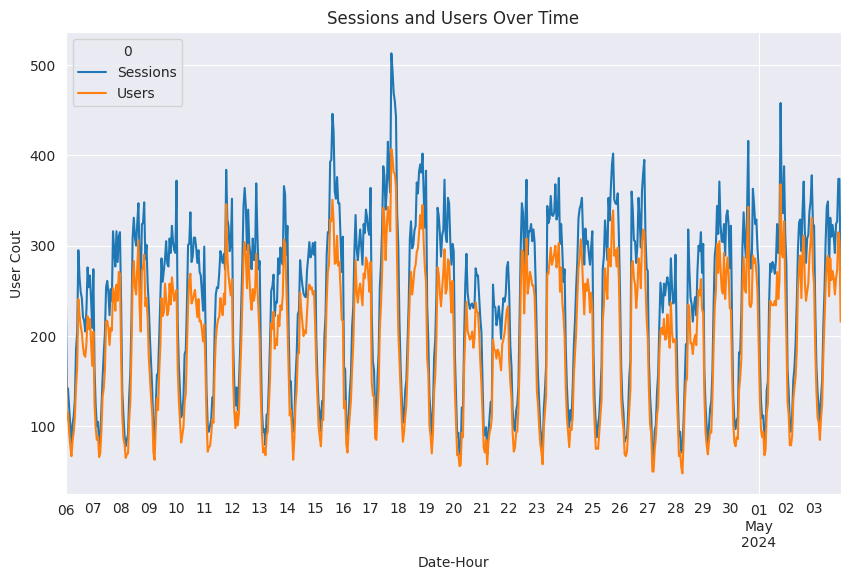

In [19]:
plt.figure(figsize = (10,6))
data.groupby('DateHour')[['Sessions','Users']].sum().plot(ax=plt.gca())
plt.title('Sessions and Users Over Time')
plt.ylabel('User Cout')
plt.xlabel('Date-Hour')
plt.show()

In [20]:
#Accroding to this graph on 16-19 most users were engaged on the website, so the 15-16 is recommended to start a campaign.

**Q2: Which marketing channel brought the highest number of users to the website, how can we use this insight to improve traffic from other sources?**

/tmp/ipykernel_1313/1232016815.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data['Channel group'], y = data['Users'], palette = 'rainbow')


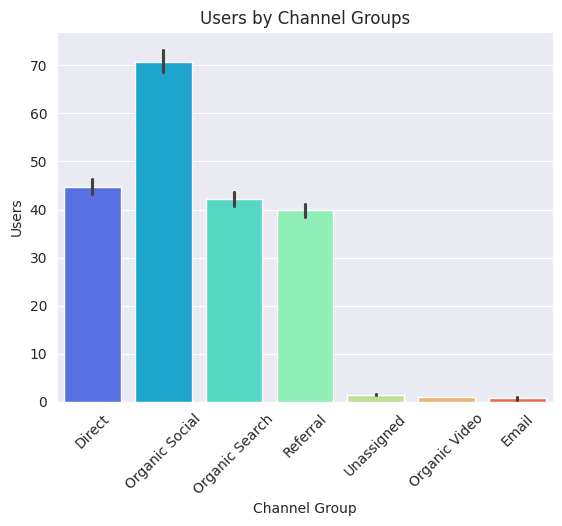

In [21]:
sns.barplot(x = data['Channel group'], y = data['Users'], palette = 'rainbow')
plt.title('Users by Channel Groups')
plt.xlabel('Channel Group')
plt.ylabel('Users')
plt.xticks(rotation = 45)
plt.show()

In [22]:
#ANALYSING THE ABOVE BARPLOT IT IS FOUND THAT THE CHANNEL "Organic Social" IS THE MOST VALUABLE CHANNEL THAT BRINGS MOST USERS TO THE WEBSITE WHILE THE CHANNELS LIKE: "Unassigned","Organic Video", AND "Email" ARE SLIGHTLY WEAK, SO, IT IS RECOMMENDED TO OPTIMIZE THE WEAKER CHANNELS AND COMPANY CAN INVEST MORE MONEY ON THE CHNNELS LIKE "DIRECT","ORGANIC SOCIAL","ORGANIC SEARCH" AND "REFERRAL"

**Q3: Which channel has the highest average engagement time, and what does that tell us about user behaviour and conent effectiveness?**

/tmp/ipykernel_1313/1683102822.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data['Channel group'], y = data['Average engagement time per session'], palette = 'magma')


Text(0.5, 1.0, 'Average Engagement Time Per Session By Channel')

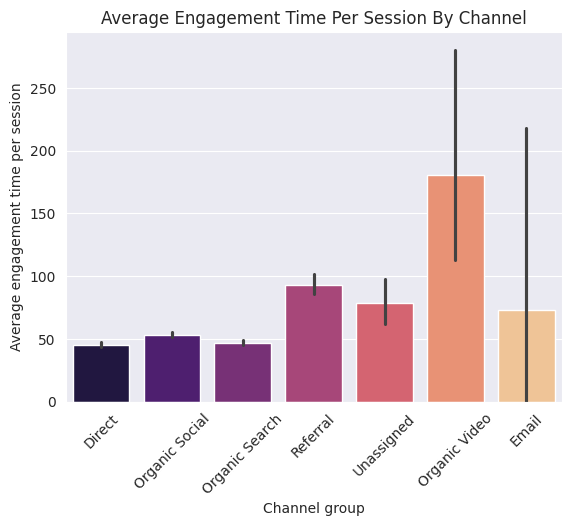

In [23]:
sns.barplot(x = data['Channel group'], y = data['Average engagement time per session'], palette = 'magma')
plt.xticks(rotation = 45)
plt.title('Average Engagement Time Per Session By Channel')

In [24]:
#BY OBSERVING THE ABOVE PLOT I FOUND THAT THE CHANNELS LIKE "Unassigned","Organic Video","Email" ARE NOT GOOD ENOUGH TO BRING USERS BUT USERS WHO ARE COMING THROUGH THESE CHANNELS ARE SPENDING MORE TIME ON WEBSITE THAN OTHER CHANNEL'S USERS, SO ITS HIGHLY RECOMMENDED THAT COMPANY SHOULD OPTIMIZE THESE CHANNELS.

**Q4: How does engagement rate vary across different traffic channels?**

/tmp/ipykernel_1313/3208069581.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data['Channel group'], y = data['Engagement rate'], palette = 'brg_r')


Text(0.5, 1.0, 'Engagement Rate By Channel')

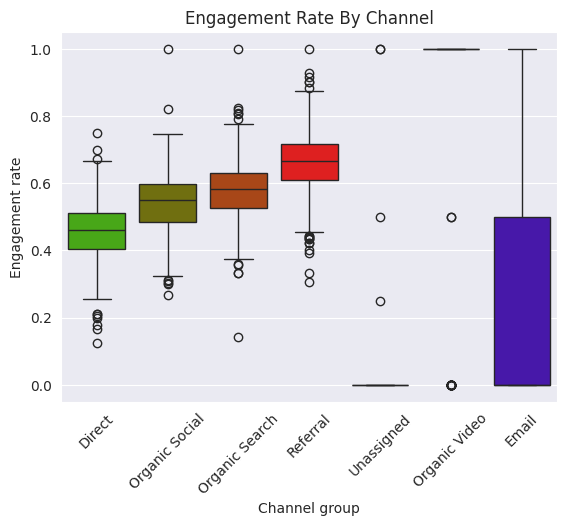

In [25]:
sns.boxplot(x = data['Channel group'], y = data['Engagement rate'], palette = 'brg_r')
plt.xticks(rotation = 45)
plt.title('Engagement Rate By Channel')

In [26]:
#BY ANALYSING THE ABOVE BOXPLOT I FOUND THAT USERS COMING FROM "Referral" CHANNEL ARE THE MOST ENGAGED,
#"EMAIL" AND "UNASSIGNED" CHANNELS HAVE VERY HIGH VARIABILITY, INDICATING INCONSISTENT USER BEHAVIOUR.
#SEVERAL OUTLIERS ARE PRESENT ACROSS CHANNELS, SUGGESTING OCCASIONAL UNUSUALLY HIGH OR LOW ENGAGEMENT SESSIONS.
#RECOMMENDATIONS:
#COMPANY SHOULD INVEST IN "Referral" and "Organic" CHANNELS
#CHANNELS LIKE "Email" and "Unassigned" NEED OPTIMIZATION AND AUDIENCE TARGETING IMPROVEMENTS BECAUSE THEIR ENGAGEMENT PERFORMANCE IS HIGHLY INCONSITENT.

**Q5: Which channels are driving more engage sessions compared to non-engaged ones, and what strategies can improve engagement in underperforming channels?**

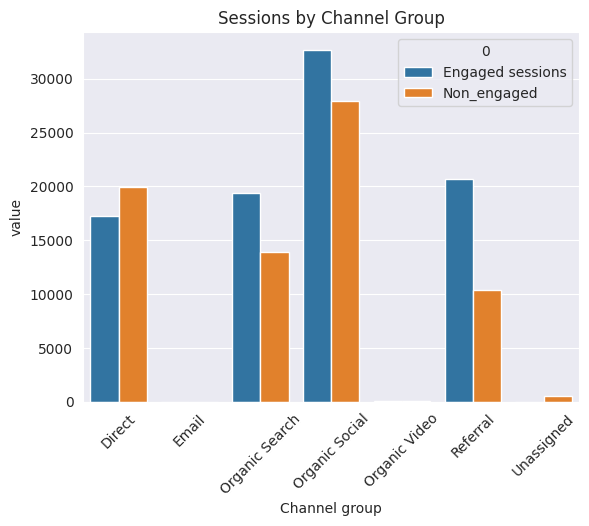

In [53]:
session_data = data.groupby('Channel group')[['Sessions','Engaged sessions']].sum().reset_index()
session_data['Non_engaged'] = session_data['Sessions'] - session_data['Engaged sessions']
session_data_melted = session_data.melt(id_vars='Channel group', value_vars=['Engaged sessions','Non_engaged'])

#session_data_melted

#plt.figure(figsize = (8,5))
sns.barplot(data = session_data_melted, x='Channel group',y='value', hue = 0)
plt.title('Sessions by Channel Group')
plt.xticks(rotation = 45)
plt.show()

In [54]:
#CHANNELS LIKE 'Organic Social', 'Organic Search and 'Referral' HAVE STRONG ENGAGEMENT SHOWING USERS ACTIVELY INTRECT.
#CONVERSELY, 'Direct' and 'Unassigned' CHANNELS HAVE MANY NO-ENGAGED SESSIONS, INDICATING A NEED FOR IMPROVED CONTENT OF USER EXPERIENCE TO CONVERT VISITORS INTO ACTIVE PARTICIPANTS.

**Q6: At what hours of the day does each channel drive the most traffic?**

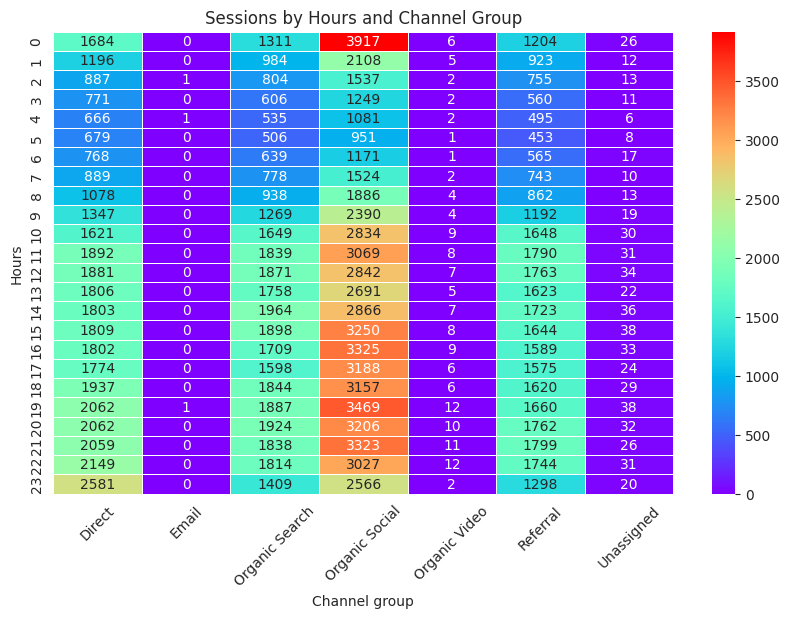

In [80]:
heatmap_data = data.groupby(['Hours','Channel group'])['Sessions'].sum().unstack().fillna(0)
#heatmap_data

plt.figure(figsize = (10,6))
sns.heatmap(heatmap_data, cmap = 'rainbow', linewidths=.5, annot = True, fmt = '.0f')
plt.title('Sessions by Hours and Channel Group')
plt.xticks(rotation = 45)
plt.show()

In [81]:
#THE HEATMAP SHOWS 'Organic Social' AND 'Organic Search' HAVE CONSISTENT HIGH TRAFFIC ACROSS HOURS. OTHER CHANNELS LIKE 'Direct' AND 'Referral' HAVE SPECIFIC PEAK HOURS. TO IMPROVE, OPTIMIZE CAMPAIGNS FOR THESE PEAK TIMES AND FOCUS ON BOOSTING LOW-TRAFFIC CHANNELS LIKE 'Email' AND 'Organic Video'.

**Q7: Is there any corelation between high traffic (sessions) and high engagement rate over time?**

Text(0.5, 1.0, 'Engagement Rate and Sessions Over Time')

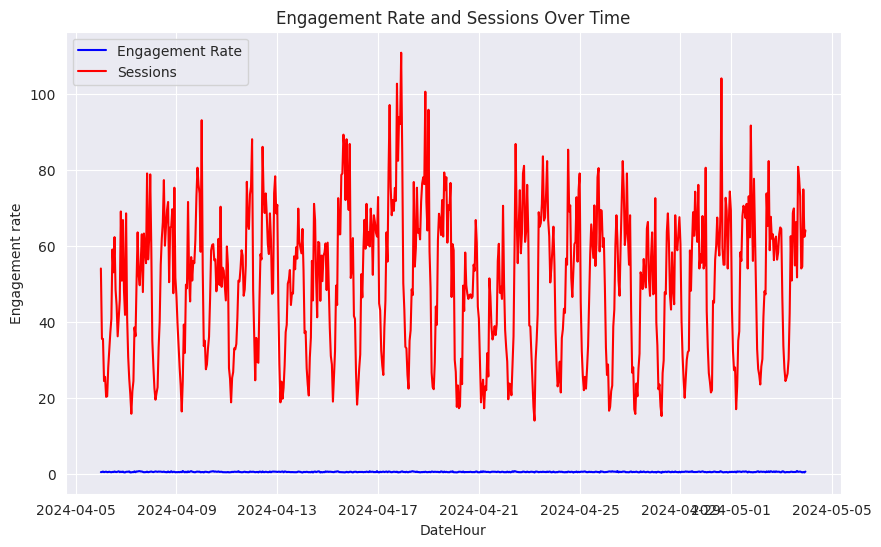

In [85]:
data_plot = data.groupby('DateHour')[['Engagement rate', 'Sessions']].mean().reset_index()
#data_plot
plt.figure(figsize = (10,6))
sns.lineplot(data = data_plot, x = 'DateHour', y = 'Engagement rate', label = 'Engagement Rate', color = 'blue')
sns.lineplot(data = data_plot, x = 'DateHour', y = 'Sessions', label = 'Sessions', color = 'red')
plt.title('Engagement Rate and Sessions Over Time')

In [ ]:
#THE PLOT SHOWS THAT WHILE THE NUMBER OF VISITORS CHANGES THROUGHOUT THE DAY, THE PERCENTAGE OF ENGAGED USERS STAYS MOSTLY FLAT AND STABLE. THIS MEANS CONTENT QUALITY IS COSISTENT, BUT TO GROW, COMPANY SHOULD TRY NEW INTERACTIVE STRATEGIES DURING HIGH-TRAFFIC HOURS TO TURN MORE OF THOSE VISITORS INTO ACTIVE USERS.

**Overall Insight**:

Most of your traffic comes from 'Organic Social' and 'Search,' but your most loyal and active users are coming from 'Referrals.' While you have many visitors, the actual engagement rate doesn't increase with traffic volume.

**Suggestions**:

**Focus on Quality**:
Invest more in 'Referral' and 'Social' channels as they bring the most active users.

**Time it Right**:
Launch your ads or posts during the specific peak hours identified in the heatmap to catch users when they are most active.
Improve the Hook: Use interactive content (like polls or videos) on high-traffic days to turn casual visitors into engaged customers.